# Convolutions

In this lab, we'll look in detail at convolutions and how they can be used to process images.

### Reading and opening images

We'll use the `skimage` library to read and process images. It's a library dedicated to image processing, which is part of the `scikit-learn` family.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import skimage

sample image shape:  (400, 600, 3)


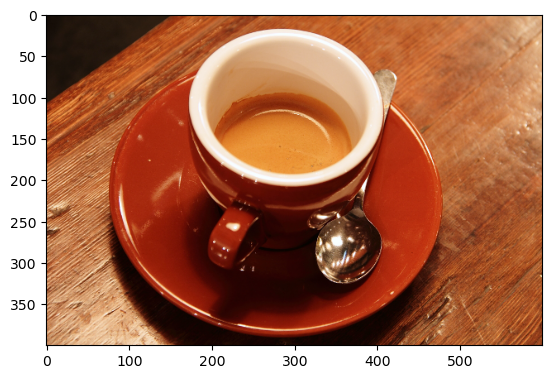

In [2]:
sample_image = skimage.data.coffee()

size = sample_image.shape
print("sample image shape: ", sample_image.shape)

plt.imshow(sample_image.astype('uint8'));

### A simple convolution filter

Before we start working on training any models, let's look at applying a convolution filter to an image. We'll use the `Conv2D` layer from Keras to do this.

In [3]:
from tensorflow.keras.layers import Conv2D

In [4]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same")

Remember: in Keras, `None` is used as a marker for tensor dimensions with dynamic size. In this case `batch_size`, `width` and `height` are all dynamic: they can depend on the input. This is a neat feature of convolutional neural networks: the same model can be used to process images of any size, because all we have to do is slide the convolutional filter across the image as much as necessary.

In [5]:
sample_image.shape

(400, 600, 3)

In [6]:
img_in = np.expand_dims(sample_image, 0).astype(float)
img_in.shape

(1, 400, 600, 3)

In [7]:
img_out = conv(img_in) # Apply the convolutional filter

The output is a tensorflow Eager Tensor - a special data structure that is used to represent the result of operations in TensorFlow. It is not a numpy array, but it can be converted to one using the `.numpy()` method:

In [8]:
np_img_out = img_out[0].numpy()
print(type(np_img_out))
print(np_img_out.shape)

<class 'numpy.ndarray'>
(400, 600, 3)


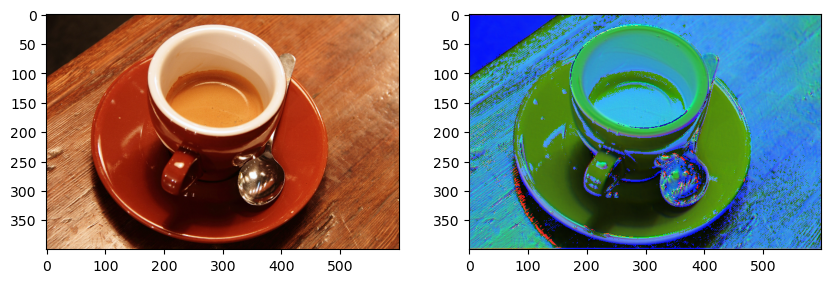

In [9]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(sample_image.astype('uint8'))
ax1.imshow(np_img_out.astype('uint8'));

As we can see, our convolutional filter was initialized randomly, so our output doesn't contain any specific meaning. Each pixel is a random combination of the pixels in the input image, in a 5x5 window.

Let's instead take a look at a convolutional feature with a clear purpose. We can build a kernel ourselves, by defining a function which will be passed to `Conv2D` Layer.
We'll create an array with 1/25 for filters, with each channel seperated. Before you move to the next cell, can you guess what this filter will do?

In [10]:
def my_kernel(shape=(5, 5, 3, 3), dtype=None):
    array = np.zeros(shape=shape, dtype="float32")
    array[:, :, 0, 0] = 1 / 25
    array[:, :, 1, 1] = 1 / 25
    array[:, :, 2, 2] = 1 / 25
    return array

Now we can use this function to initialize a `Conv2D` layer:

In [11]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same", kernel_initializer=my_kernel)

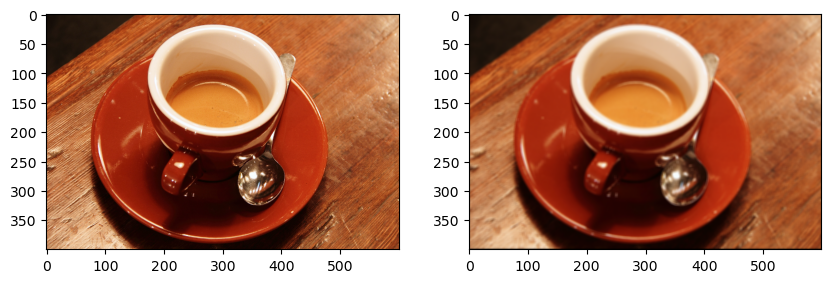

In [12]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'));

Hopefully you can tell what this filter does!

**Exercise**
- There are a number of settings when we define our Conv2D layer. Try changing the following parameters to get a sense of how they impact the result:
- kernel_size: try different sizes
- padding: try 'valid' instead of 'same' (hint: this may change the size of the output)

In [13]:
# Your Code Here
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define a simple model with Conv2D layer
model = Sequential()

# Try different kernel sizes and padding settings
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(64, 64, 3)))  # (3x3 kernel, same padding)
# model.add(Conv2D(32, kernel_size=(5, 5), padding='same', activation='relu', input_shape=(64, 64, 3)))  # (5x5 kernel, same padding)
# model.add(Conv2D(32, kernel_size=(7, 7), padding='same', activation='relu', input_shape=(64, 64, 3)))  # (7x7 kernel, same padding)

# Or try with 'valid' padding
# model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(64, 64, 3)))

model.add(MaxPooling2D(pool_size=(2, 2)))  # Pooling layer
model.add(Flatten())  # Flatten the output to feed into dense layers
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))  # Output layer for 10 classes

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summarize the model
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 32768)             0         
                                                                 
 dense (Dense)               (None, 128)               4194432   
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 4,196,618
Trainable params: 4,196,618
Non-trainable params: 0
______________________________________________

### Working on edge detection on Grayscale image

Using a grayscale image, let's build an "edge detector" using a convolutional filter. Some filters pre-date the deep learning era and are still used today. For example, the Sobel filter is used to detect edges in images. These easy-to-compute filters were used in the early days of computer vision and are still useful now.

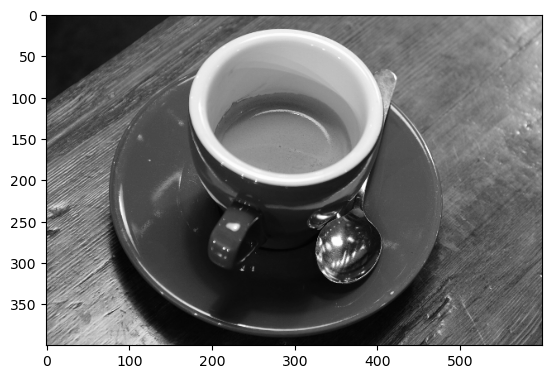

In [14]:
# convert image to greyscale
grey_sample_image = sample_image.mean(axis=2)

# add the channel dimension even if it's only one channel so
# to be consistent with Keras expectations.
grey_sample_image = grey_sample_image[:, :, np.newaxis]

# matplotlib does not like the extra dim for the color channel
# when plotting gray-level images. Let's use squeeze:
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray);

**Exercise**
- Build an edge detector using `Conv2D` on greyscale image by defining the kernel inside `my_kernel`.
- You may experiment with several kernels to find a way to detect edges. The following article contains specific examples of kernels that you can use:
- https://en.wikipedia.org/wiki/Kernel_(image_processing)
- Try different kernels and see the impact on the output.

In [ ]:
def my_kernel(shape=(4, 5, 2, 3), dtype=None):
    array = None
    raise NotImplementedError("Replace the line above with your implementation")
    array = array.reshape(*shape)
    return array

conv = Conv2D(filters=1, kernel_size=(3, 3), padding="same", kernel_initializer=my_kernel)

img_in = np.expand_dims(grey_sample_image, 0) # Reshape into a batch of size 1
img_out = conv(img_in) # Apply the convolutional filter
np_img_out = img_out[0].numpy() # Convert to numpy array

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray)
ax1.imshow(np_img_out.astype(np.uint8), cmap=plt.cm.gray);


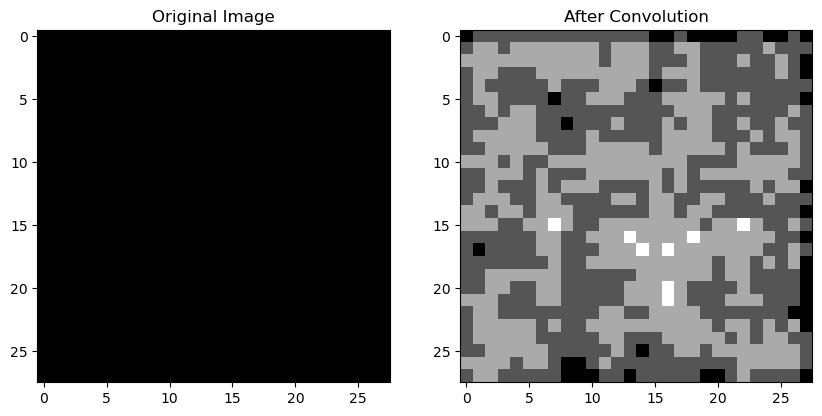

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D
import tensorflow as tf

# Define a custom kernel function
def my_kernel(shape=(4, 5, 2, 3), dtype=None):
    # Create a custom kernel (array) with random values
    # shape=(4, 5, 2, 3) means 2 filters of size (4x5) with 3 channels
    array = np.random.rand(*shape).astype(np.float32)  # Random initialization
    return array

# Assume `grey_sample_image` is already loaded and has the appropriate shape
# Example:
grey_sample_image = np.random.rand(28, 28)  # This is a placeholder, replace with actual image

# Reshape the image to have 4 dimensions: (batch_size, height, width, channels)
img_in = np.expand_dims(grey_sample_image, -1)  # Shape becomes (28, 28, 1)
img_in = np.expand_dims(img_in, 0)  # Now the shape becomes (1, 28, 28, 1)

# Define the Conv2D layer using the custom kernel initializer
conv = Conv2D(filters=1, kernel_size=(3, 3), padding="same", kernel_initializer=my_kernel)

# Apply the convolutional filter
img_out = conv(img_in)  # Apply the filter to the image

# Convert to numpy array (since TensorFlow tensors are returned)
np_img_out = img_out[0].numpy()

# Plot the original and the output images
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))

# Show the original image
ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
ax0.set_title('Original Image')

# Show the image after applying the convolutional filter
ax1.imshow(np_img_out.astype(np.uint8), cmap=plt.cm.gray)
ax1.set_title('After Convolution')

plt.show()


### Pooling and strides with convolutions

**Exercise**
- Use `MaxPool2D` to apply a 2x2 max pool with strides 2 to the image. What is the impact on the shape of the image?
- Use `AvgPool2D` to apply an average pooling.
- Is it possible to compute a max pooling and an average pooling with well chosen kernels?

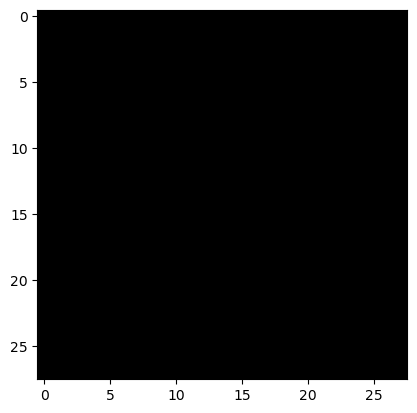

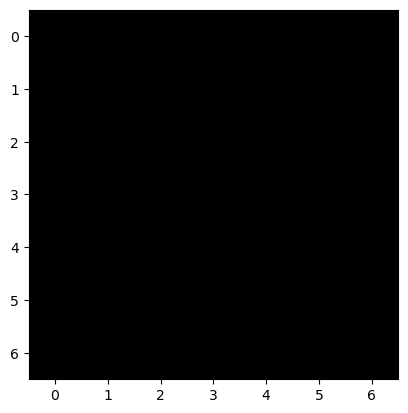

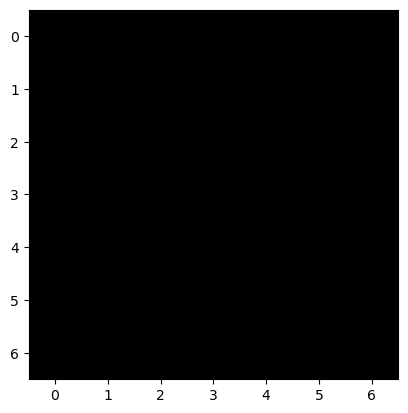

In [21]:
from tensorflow.keras.layers import MaxPool2D, AvgPool2D

# You can use `img_in` from above as input to the pooling layers

plt.figure()
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray);

pool = MaxPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")

img_out = pool(img_in)
np_img_out = img_out[0].numpy()

plt.figure()
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)),
              cmap=plt.cm.gray);

pool = AvgPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")

img_out = pool(img_in)
np_img_out = img_out[0].numpy()

plt.figure()
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)),
                cmap=plt.cm.gray);

## Loading a JPEG file as a numpy array

Let's use [scikit-image](http://scikit-image.rg) to load the content of a JPEG file into a numpy array:

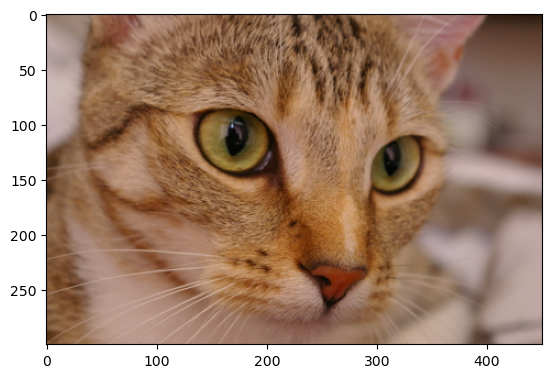

In [22]:
from skimage.io import imread

image = skimage.data.cat()
plt.imshow(image);

## Resizing images, handling data types and dynamic ranges

While convolutions can handle inputs of any size, it is often useful to resize images to a fixed size. This is particularly important for training deep learning models:

- for **image classification**, most networks expect a specific **fixed input size**;

- for **object detection** and instance segmentation, networks have more flexibility but the image should have **approximately the same size as the training set images**.

Furthermore **large images can be much slower to process** than smaller images (the number of pixels varies quadratically with the height and width).

In [23]:
from skimage.transform import resize

lowres_image = resize(image, (50, 50), mode='reflect', anti_aliasing=True)
lowres_image.shape

(50, 50, 3)

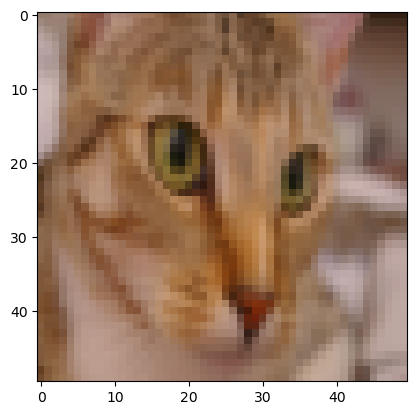

In [24]:
plt.imshow(lowres_image, interpolation='nearest');

The values of the pixels of the low resolution image are computed from by combining the values of the pixels in the high resolution image. The result is therefore represented as floating points.

## Using a pretrained model

Objectives:

- Load a pre-trained ResNet50 pre-trained model using Keras Zoo
- Use the model to classify an image
- Use the model to classify an image from the webcam

Let's start with loading ResNet50, a well-established method for image classification. The ResNet50 "application" takes two key parameters here: firstly, `include_top` indicates whether we want to include the last layer of the network (the classification layer) or not. Secondly, `weights` indicates whether we want to load the weights of a model that has been pre-trained on ImageNet or not.

In [25]:
from tensorflow.keras.applications.resnet50 import ResNet50

model = ResNet50(include_top=True, weights='imagenet')
model.compile(optimizer='sgd', loss='categorical_crossentropy')

102967424/102967424 [==============================] - 15s 0us/step


In [26]:
print(model.summary())

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

### Classification of an image

**Exercise**
- Reshape the `cat` image to the shape `(224, 224, 3)` using `resize` from `skimage.transform`
- Use `preprocess_input` from `tensorflow.keras.applications.imagenet_utils` to preprocess the image
- Use `predict` to classify the image

Documentation for each method:
- [resize](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize)
- [preprocess_input](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input)
- [predict](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict)

In [ ]:
#from keras.applications.resnet50 import preprocess_input, decode_predictions

import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras.applications import VGG16  
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from tensorflow.keras.preprocessing import image

# Load your cat image (replace with the actual image path)
cat_image_path = 'lowres_image'
cat_image = image.load_img(cat_image_path)

# Step 1: Resize the image to (224, 224, 3)
cat_image_resized = resize(np.array(cat_image), (224, 224), mode='reflect')  # Resize image
cat_image_resized = np.dstack([cat_image_resized] * 3)  # Convert to 3 channels if needed

# Step 2: Preprocess the image
cat_image_resized = np.expand_dims(cat_image_resized, axis=0)  # Add batch dimension (1, 224, 224, 3)
cat_image_resized = preprocess_input(cat_image_resized)  # Preprocess for ImageNet model

# Step 3: Load a pre-trained model (VGG16 in this case)
model = VGG16(weights='imagenet')

# Step 4: Predict the class of the image
predictions = model.predict(cat_image_resized)

# Decode and print the top 3 predictions
from tensorflow.keras.applications.imagenet_utils import decode_predictions

decoded_predictions = decode_predictions(predictions, top=3)[0]
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"Prediction {i+1}: {label} (Score: {score:.2f})")

# Display the original and resized images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Show the original cat image
axes[0].imshow(cat_image)
axes[0].set_title('Original Cat Image')
axes[0].axis('off')

# Show the resized cat image
axes[1].imshow(cat_image_resized[0])  # The batch dimension is 0, so we use cat_image_resized[0]
axes[1].set_title('Resized Cat Image (224x224)')
axes[1].axis('off')

plt.show()


##  Taking snapshots from the webcam

For this section, we will take an image from your laptop webcam and classify it. If you feel uncomfortable doing this section, you can skip it and use a photo of your choice from the web instead.

In [29]:
import cv2

def camera_grab(camera_id=0, fallback_filename=None):
    camera = cv2.VideoCapture(camera_id)
    try:
        # take 10 consecutive snapshots to let the camera automatically tune
        # itself and hope that the contrast and lighting of the last snapshot
        # is good enough.
        for i in range(10):
            snapshot_ok, image = camera.read()
        if snapshot_ok:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            print("WARNING: could not access camera")
            if fallback_filename:
                image = imread(fallback_filename)
    finally:
        camera.release()
    return image

dtype: uint8, shape: (480, 640, 3), range: (27, 255)


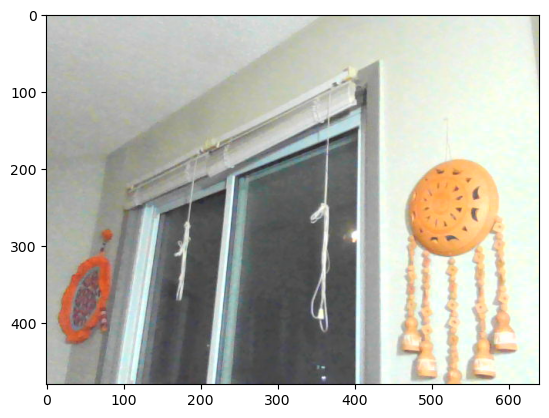

In [32]:
image = camera_grab(camera_id=0, fallback_filename=None)
plt.imshow(image)
print("dtype: {}, shape: {}, range: {}".format(
    image.dtype, image.shape, (image.min(), image.max())))


### Exercise

Apply the same preprocessing as before and classify the image. What are your results?

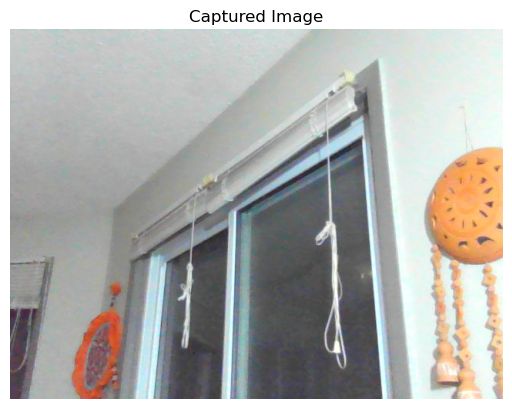

dtype: uint8, shape: (480, 640, 3), range: (14, 255)
1/1 [==============================] - 1s 675ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.57695667346034..-102.93900050352366].


Prediction 1: matchstick (Score: 0.08)
Prediction 2: nematode (Score: 0.05)
Prediction 3: lighter (Score: 0.03)


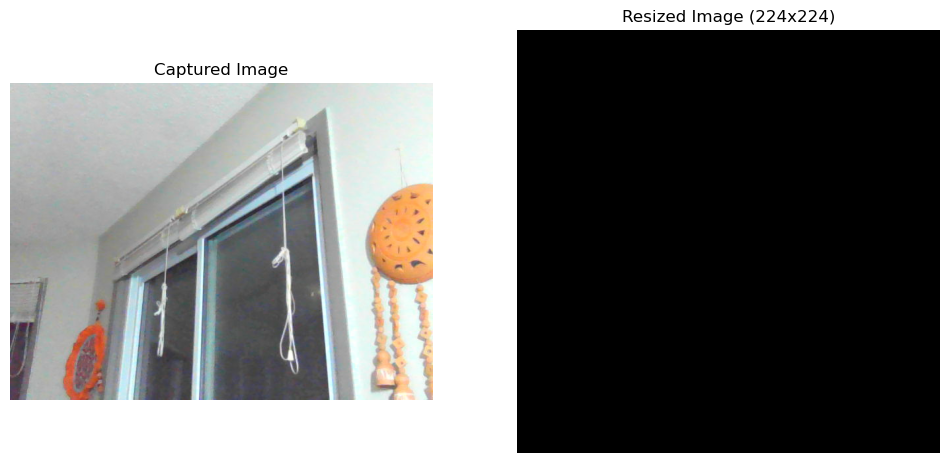

In [36]:


import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.imagenet_utils import preprocess_input, decode_predictions

# Capture the image (assumes camera_grab is a function that captures an image)
image = camera_grab(camera_id=0, fallback_filename=None)

# Show the image and its details
plt.imshow(image)
plt.title("Captured Image")
plt.axis('off')
plt.show()

print("dtype: {}, shape: {}, range: {}".format(image.dtype, image.shape, (image.min(), image.max())))

# Step 1: Resize the image to (224, 224, 3)
# Resize the image to 224x224 and ensure the image has 3 channels (RGB)
image_resized = resize(image, (224, 224, 3), mode='reflect')  # Resize to 224x224 with 3 channels

# Step 2: Preprocess the image for the model
image_resized = np.expand_dims(image_resized, axis=0)  # Add batch dimension (1, 224, 224, 3)
image_resized = preprocess_input(image_resized)  # Preprocess for ImageNet model

# Step 3: Load a pre-trained model (VGG16 in this case)
model = VGG16(weights='imagenet')

# Step 4: Predict the class of the image
predictions = model.predict(image_resized)

# Decode and print the top 3 predictions
decoded_predictions = decode_predictions(predictions, top=3)[0]
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"Prediction {i+1}: {label} (Score: {score:.2f})")

# Display the original image and resized image for reference
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Show the original image captured from the camera
axes[0].imshow(image)
axes[0].set_title('Captured Image')
axes[0].axis('off')

# Show the resized image
axes[1].imshow(image_resized[0])  # Remove the batch dimension for display
axes[1].set_title('Resized Image (224x224)')
axes[1].axis('off')

plt.show()